# Cabeza de detección tipo grid y pérdidas 

tomar el mapa de características que entregan el backbone y el CBAM y construir la cabeza que **encierra los huesos en cajas**.

| Recibe | Entrega |
|---|---|
| mapa `[B, 256, 16, 16]` (backbone + CBAM) | logits `[B, 8, 16, 16]`: por celda, ¿hay hueso? (1) · ¿dónde está su caja? (4) · ¿qué hueso es? (3) |

Cada sección sigue el mismo patrón: **idea → código corto → controles → gráfico.**

1. IoU · 2. De cajas a celdas · 3. La cabeza · 4. Las pérdidas · 5. Mini-overfit · 6. Decodificar y enchufar el NMS · 7. Resumen

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.colors import ListedColormap

SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GRID_S = 16                      # el grid es de 16 x 16 celdas
IMG_SIZE = 256                   # imagen de 256 x 256 px
STRIDE = IMG_SIZE // GRID_S      # cada celda mide 16 px
CH_OBJ, CH_BOX, CH_CLS = 0, slice(1, 5), slice(5, 8)      # canales de la salida [B, 8, S, S]
CLASS_NAMES = {1: "sacro", 2: "coxal_izquierdo", 3: "coxal_derecho"}

# Batch fijo de Daniela: 6 cortes con 12 cajas
batch = torch.load("evidencias/batch_fijo.pt")
imgs = batch["imgs"]                                       # [6, 1, 256, 256]
targets = [{"boxes": b, "labels": l, "case_id": c, "slice_index": s}
           for b, l, c, s in zip(batch["boxes"], batch["labels"], batch["case_ids"], batch["slice_index"])]
print(f"torch {torch.__version__} | {DEVICE} | imágenes {tuple(imgs.shape)} | cajas: {sum(len(t['boxes']) for t in targets)}")


def dibujar_caja(ax, caja, color, lw=2, ls="-", texto=None):
    x1, y1, x2, y2 = [float(v) for v in caja]
    ax.add_patch(Rectangle((x1 - 0.5, y1 - 0.5), x2 - x1, y2 - y1, fill=False, ec=color, lw=lw, ls=ls))   # -0.5: imshow centra cada píxel en su coordenada entera
    if texto:
        ax.text(x1 - 0.5, max(y1 - 3, 6), texto, fontsize=7, weight="bold", bbox=dict(boxstyle="square,pad=0.15", fc=color, ec="none", alpha=0.85))


def dibujar_grid(ax):
    for g in range(0, IMG_SIZE + 1, STRIDE):
        ax.axhline(g - 0.5, lw=0.3, c="c")
        ax.axvline(g - 0.5, lw=0.3, c="c")

torch 2.14.1+cpu | cpu | imágenes (6, 1, 256, 256) | cajas: 12


## 1. IoU: qué tanto se parecen dos cajas

$$IoU(A,B)=\frac{\text{área}(A\cap B)}{\text{área}(A\cup B)}$$

Vale 1 si las cajas coinciden y 0 si no se tocan. Es la métrica del proyecto y entra en la pérdida de caja como `1 − IoU`.

Dos detalles que evitan errores silenciosos: `clamp(min=0)` (si las cajas no se tocan, el ancho de la intersección saldría negativo y daría un área falsa) y `eps` (una caja de área cero daría 0/0 = NaN).

**Ejemplo a mano:** A = (0,0,10,10) y B = (5,5,15,15): intersección 5×5 = 25, unión 100 + 100 − 25 = 175, IoU = 25/175 = 1/7 ≈ 0.143.

In [2]:
def box_iou(boxes1, boxes2, eps=1e-7):
    """IoU entre cajas xyxy en píxeles. Acepta formas [..., 4] compatibles por broadcasting."""
    b1, b2 = boxes1.float(), boxes2.float()
    inter_w = (torch.minimum(b1[..., 2], b2[..., 2]) - torch.maximum(b1[..., 0], b2[..., 0])).clamp(min=0)   # clamp: si no se tocan, 0
    inter_h = (torch.minimum(b1[..., 3], b2[..., 3]) - torch.maximum(b1[..., 1], b2[..., 1])).clamp(min=0)
    inter = inter_w * inter_h
    area1 = (b1[..., 2] - b1[..., 0]).clamp(min=0) * (b1[..., 3] - b1[..., 1]).clamp(min=0)
    area2 = (b2[..., 2] - b2[..., 0]).clamp(min=0) * (b2[..., 3] - b2[..., 1]).clamp(min=0)
    return inter / (area1 + area2 - inter + eps)           # eps: evita 0/0 con cajas de área cero


def pairwise_iou(boxes1, boxes2):
    """Matriz [N, M] con el IoU de cada caja de boxes1 contra cada caja de boxes2 (la usará el NMS)."""
    return box_iou(boxes1[:, None, :], boxes2[None, :, :])

IoU: los 3 casos de control pasan y una caja de área cero no produce NaN


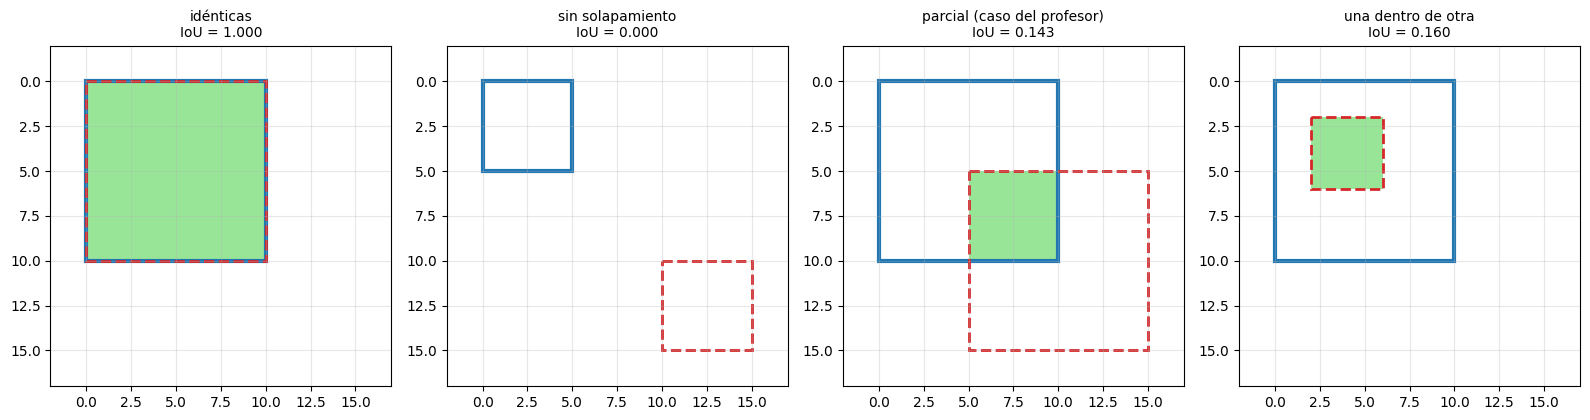

In [3]:
def caja(x1, y1, x2, y2):
    return torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)

# Controles (los 3 casos del profesor + caja vacía)
assert abs(box_iou(caja(0,0,10,10), caja(0,0,10,10)).item() - 1.0) < 1e-6          # idénticas -> 1
assert abs(box_iou(caja(0,0,5,5), caja(10,10,15,15)).item()) < 1e-6                # sin solapamiento -> 0
assert abs(box_iou(caja(0,0,10,10), caja(5,5,15,15)).item() - 25 / 175) < 1e-6     # caso del profesor: 1/7
assert torch.isfinite(box_iou(caja(5,5,5,5), caja(5,5,5,5))).all()                 # caja de área cero: sin NaN
print("IoU: los 3 casos de control pasan y una caja de área cero no produce NaN")

pares = [((0,0,10,10), (0,0,10,10), "idénticas"), ((0,0,5,5), (10,10,15,15), "sin solapamiento"),
         ((0,0,10,10), (5,5,15,15), "parcial (caso del profesor)"), ((0,0,10,10), (2,2,6,6), "una dentro de otra")]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (A, B, titulo) in zip(axes, pares):
    ix1, iy1, ix2, iy2 = max(A[0], B[0]), max(A[1], B[1]), min(A[2], B[2]), min(A[3], B[3])
    if max(0, ix2 - ix1) * max(0, iy2 - iy1) > 0:
        ax.add_patch(Rectangle((ix1, iy1), ix2 - ix1, iy2 - iy1, fc="limegreen", alpha=0.5))     # intersección
    ax.add_patch(Rectangle((A[0], A[1]), A[2] - A[0], A[3] - A[1], fill=False, ec="tab:blue", lw=3))
    ax.add_patch(Rectangle((B[0], B[1]), B[2] - B[0], B[3] - B[1], fill=False, ec="tab:red", lw=2, ls="--"))
    ax.set_xlim(-2, 17); ax.set_ylim(17, -2); ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_title(f"{titulo}\nIoU = {box_iou(caja(*A), caja(*B)).item():.3f}", fontsize=10)
plt.tight_layout()
plt.show()

## 2. De cajas a celdas: qué debe responder cada celda

El dataset entrega cada caja como `(x_min, y_min, x_max, y_max)` en píxeles. La red, en cambio, responde **por celda**. Hace falta traducir:

- **Celda responsable:** la que contiene el **centro** de la caja (no se usa IoU para asignar; no hay anclas).
- `tx, ty`: posición del centro **dentro de su celda**, en [0, 1). `tw, th`: ancho y alto divididos entre 256.
- Todas las demás celdas son **fondo**.

Así, todas las celdas (que comparten los mismos pesos) responden lo mismo: "el centro está a esta fracción dentro de mí". Es la misma codificación del CenterNet de S7_2.

**Ejemplo a mano:** caja (40,50,104,114): centro (72, 82), tamaño 64×64 → `col = floor(72/16) = 4`, `fila = floor(82/16) = 5`, `tx = 0.5`, `ty = 0.125`, `tw = th = 0.25`.

In [4]:
def encode_boxes(boxes_xyxy, img_size=IMG_SIZE, grid_s=GRID_S):
    """Cajas xyxy en px [N,4] -> (fila [N], columna [N], t [N,4] = tx, ty, tw, th)."""
    stride = img_size / grid_s
    b = boxes_xyxy.float()
    cx, cy = (b[:, 0] + b[:, 2]) / 2, (b[:, 1] + b[:, 3]) / 2          # centro de la caja
    w, h = b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]
    col = (cx / stride).floor().clamp(0, grid_s - 1).long()             # celda que contiene el centro
    row = (cy / stride).floor().clamp(0, grid_s - 1).long()
    t = torch.stack([cx / stride - col, cy / stride - row, w / img_size, h / img_size], dim=1)   # posición dentro de la celda y tamaño relativo
    return row, col, t


def decode_boxes(row, col, t, img_size=IMG_SIZE, grid_s=GRID_S):
    """Inversa de encode_boxes: (fila, columna, t) -> cajas xyxy en px [N,4]."""
    stride = img_size / grid_s
    cx = (col.float() + t[:, 0]) * stride
    cy = (row.float() + t[:, 1]) * stride
    w, h = t[:, 2] * img_size, t[:, 3] * img_size
    return torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dim=1)

In [5]:
# Controles
r, c, t = encode_boxes(torch.tensor([[40., 50., 104., 114.]]))
assert (r.item(), c.item()) == (5, 4) and torch.allclose(t, torch.tensor([[0.5, 0.125, 0.25, 0.25]]))     # caja a mano
todas = torch.cat([t_["boxes"] for t_ in targets]).float()
rows, cols, tt = encode_boxes(todas)
assert (decode_boxes(rows, cols, tt) - todas).abs().max().item() < 1e-3                                     # ida y vuelta con las 12 cajas reales
print("Codificación: la caja a mano sale como se calculó y la ida y vuelta con las 12 cajas reales es exacta")

Codificación: la caja a mano sale como se calculó y la ida y vuelta con las 12 cajas reales es exacta


Ahora los tensores objetivo, del mismo tamaño que la salida de la red:

| Tensor | Forma | Contenido |
|---|---|---|
| `obj_t` | `[B, 16, 16]` | 1 en la celda responsable de una caja, 0 en el fondo |
| `box_t` | `[B, 16, 16, 4]` | `tx, ty, tw, th` de esa caja |
| `cls_t` | `[B, 16, 16]` | clase 0, 1 o 2 (el dataset usa 1, 2, 3); **−1** en el fondo |

Si dos centros caen en la misma celda, gana la caja más grande y se cuenta la colisión.

In [6]:
def build_targets(targets, grid_s=GRID_S, img_size=IMG_SIZE, num_classes=3):
    """targets: lista de dicts con 'boxes' [N,4] (xyxy, px) y 'labels' [N] (1..num_classes).
    Devuelve obj_t [B,S,S], box_t [B,S,S,4], cls_t [B,S,S] (0..2; -1 en el fondo) y n_collisions."""
    B = len(targets)
    obj_t = torch.zeros(B, grid_s, grid_s)
    box_t = torch.zeros(B, grid_s, grid_s, 4)
    cls_t = torch.full((B, grid_s, grid_s), -1, dtype=torch.long)
    n_collisions = 0
    for b, tgt in enumerate(targets):
        boxes = torch.as_tensor(tgt["boxes"]).float().reshape(-1, 4)
        labels = torch.as_tensor(tgt["labels"]).long().reshape(-1)
        if boxes.shape[0] == 0:
            continue                                                   # imagen sin cajas: todo es fondo
        if labels.min() < 1 or labels.max() > num_classes:
            raise ValueError(f"labels fuera de 1..{num_classes}: {labels.tolist()}")
        row, col, t = encode_boxes(boxes, img_size, grid_s)
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        for k in torch.argsort(areas, stable=True).tolist():           # de menor a mayor área: en una colisión gana la más grande
            i, j = row[k].item(), col[k].item()
            if obj_t[b, i, j] == 1:
                n_collisions += 1
            obj_t[b, i, j] = 1
            box_t[b, i, j] = t[k]
            cls_t[b, i, j] = labels[k] - 1                             # labels 1..3 -> 0..2
    return {"obj_t": obj_t, "box_t": box_t, "cls_t": cls_t, "n_collisions": n_collisions}

12 cajas = 12 celdas con hueso + 0 colisiones | fracción de celdas con hueso: 0.0078 (≈ 1 de cada 128)
  sacro            2 celdas
  coxal_izquierdo  6 celdas
  coxal_derecho    4 celdas


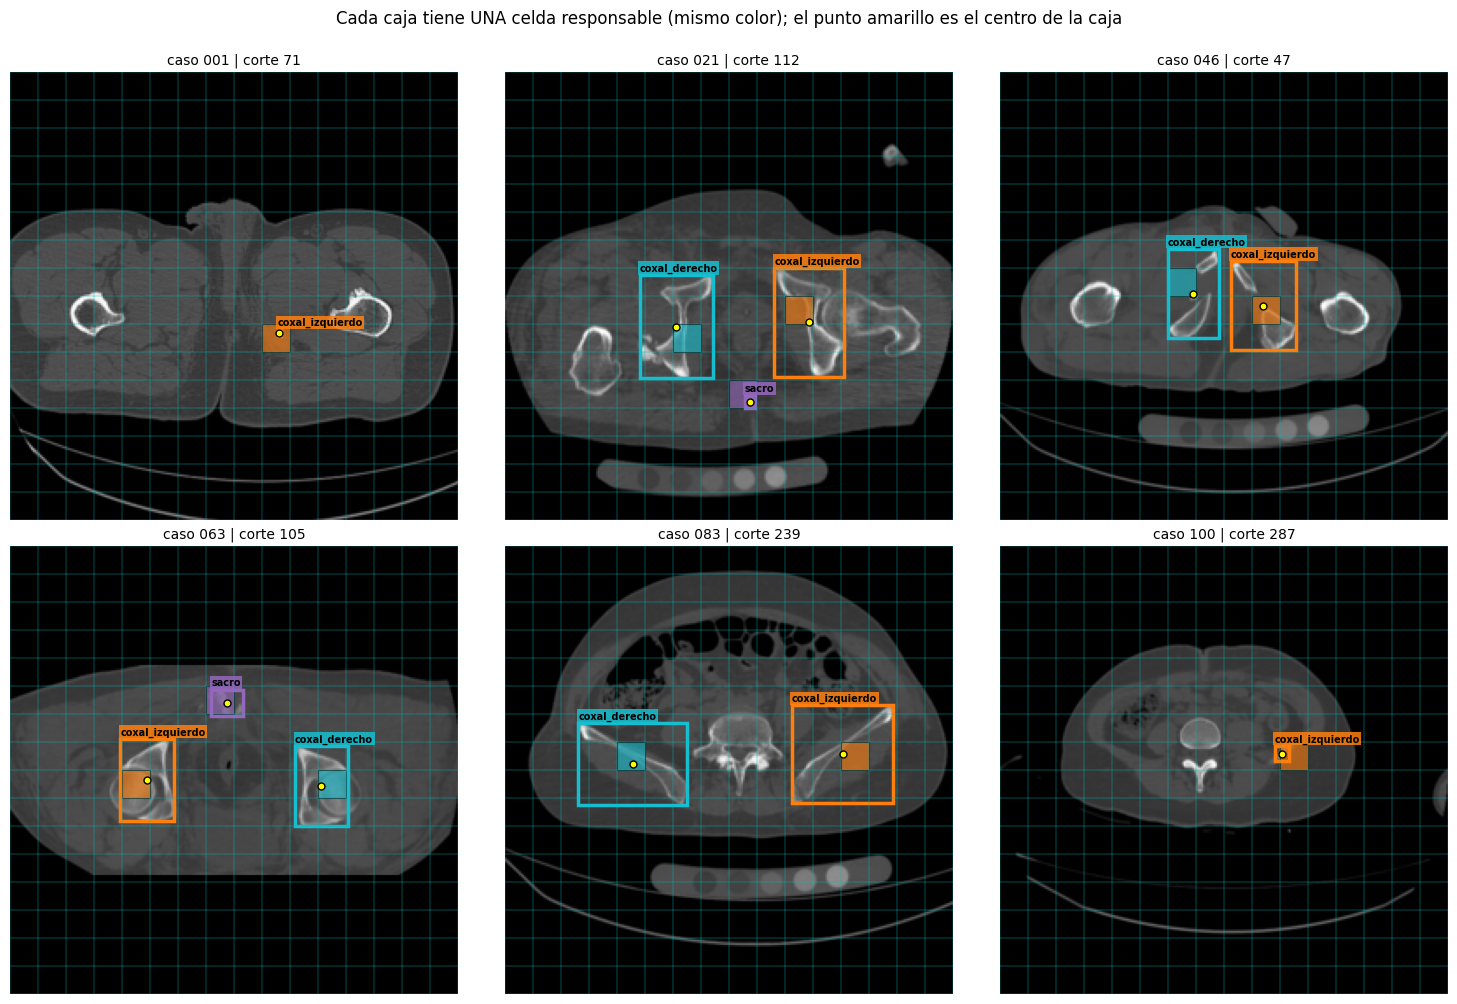

In [7]:
T = build_targets(targets)
n_cajas, n_pos = sum(len(t_["boxes"]) for t_ in targets), int(T["obj_t"].sum())

# Controles
assert n_cajas == n_pos + T["n_collisions"]                                    # cada caja tiene su celda (o es una colisión)
assert bool(((T["obj_t"] == 1) == (T["cls_t"] >= 0)).all())                    # celda con hueso <=> tiene clase
img_B = {"boxes": torch.tensor([[100., 100., 160., 160.], [124., 124., 140., 140.]]), "labels": torch.tensor([1, 2])}
TB = build_targets([img_B])                                                    # dos centros en la celda (8, 8)
assert TB["n_collisions"] == 1 and TB["cls_t"][0, 8, 8].item() == 0            # gana la caja grande (sacro)
print(f"{n_cajas} cajas = {n_pos} celdas con hueso + {T['n_collisions']} colisiones | fracción de celdas con hueso: {T['obj_t'].mean().item():.4f} (≈ 1 de cada 128)")
for k, nombre in CLASS_NAMES.items():
    print(f"  {nombre:<16} {int((T['cls_t'] == k - 1).sum())} celdas")

COLORES = {1: "#9467bd", 2: "#ff7f0e", 3: "#17becf"}                           # sacro, coxal izquierdo, coxal derecho
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for k, ax in enumerate(axes.ravel()):
    t_ = targets[k]
    ax.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
    dibujar_grid(ax)
    for i, j in T["obj_t"][k].nonzero().tolist():                              # celda responsable, del color de su clase
        cl = int(T["cls_t"][k, i, j]) + 1
        ax.add_patch(Rectangle((j * STRIDE - 0.5, i * STRIDE - 0.5), STRIDE, STRIDE, fc=COLORES[cl], alpha=0.6, ec="black", lw=0.8))
    for b, lab in zip(t_["boxes"], t_["labels"]):
        dibujar_caja(ax, b, COLORES[int(lab)], lw=2.5, texto=CLASS_NAMES[int(lab)])
        ax.plot((float(b[0]) + float(b[2])) / 2 - 0.5, (float(b[1]) + float(b[3])) / 2 - 0.5, "o", color="yellow", ms=5, mec="black")
    ax.set_title(f"caso {t_['case_id']} | corte {t_['slice_index']}", fontsize=10)
    ax.axis("off")
plt.suptitle("Cada caja tiene UNA celda responsable (mismo color); el punto amarillo es el centro de la caja", y=1.0)
plt.tight_layout()
plt.show()

## 3. La cabeza de detección

**Arquitectura:** conv 3×3 (256→128) → GroupNorm → ReLU → conv 1×1 (128→8). Sale en **logits** (sin activación); la sigmoide y el softmax se aplican en la pérdida y al decodificar.

| Canal | Contenido |
|---|---|
| 0 | objectness: ¿hay un hueso con su centro aquí? |
| 1–4 | `tx, ty, tw, th` |
| 5–7 | clase: sacro, coxal izquierdo, coxal derecho |

- La **3×3** deja que cada celda mire a sus vecinas (las cajas llegan a ~4 celdas de ancho).
- **GroupNorm** no depende del tamaño del batch.
- **Sesgos iniciales (priors):** sin ellos, la red arranca con P(objeto) ≈ 50 % en las 256 celdas y los falsos positivos dominan la pérdida. Objectness arranca en la fracción real de celdas con hueso (0.78 %), y el tamaño inicial de la caja es el **20 % de la imagen (51 px)**, el que mejor cubre a las 12 cajas reales (con 13 % el mejor IoU medio era 0.33; con 20 %, 0.42).

Para no depender de Miguel ni de Annie, aquí usamos un mapa de características **sintético y fijo** (uno por imagen). El backbone real se conecta al integrar.

In [8]:
class GridDetectionHead(nn.Module):
    """Mapa [B, 256, S, S] -> logits [B, 8, S, S]: canal 0 = objectness, 1-4 = tx, ty, tw, th, 5-7 = clases."""
    def __init__(self, in_channels=256, hidden=128, num_classes=3, obj_prior=0.0078, wh_prior=0.20):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1, bias=False),   # 3x3: cada celda mira a sus vecinas
            nn.GroupNorm(8, hidden),                                    # no depende del tamaño del batch
            nn.ReLU(inplace=True),
        )
        self.pred = nn.Conv2d(hidden, 1 + 4 + num_classes, 1)
        with torch.no_grad():                                           # sesgos iniciales (priors)
            self.pred.bias.zero_()                                      # tx, ty = 0.5: el centro de la celda
            self.pred.bias[CH_OBJ] = math.log(obj_prior / (1 - obj_prior))   # al inicio: "casi nunca hay hueso"
            self.pred.bias[3:5] = math.log(wh_prior / (1 - wh_prior))        # tamaño inicial de la caja

    def forward(self, x):
        return self.pred(self.conv(x))


def split_head_output(out):
    """[B,8,S,S] -> obj_logit [B,S,S], box_logit [B,S,S,4], cls_logit [B,S,S,3]."""
    return out[:, CH_OBJ], out[:, CH_BOX].permute(0, 2, 3, 1), out[:, CH_CLS].permute(0, 2, 3, 1)

Cabeza: salida (6, 8, 16, 16) | 296,200 parámetros | P(objeto) inicial = 0.0059 | el gradiente llega al mapa de entrada


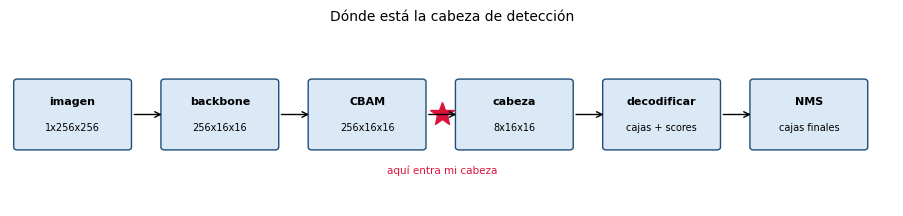

In [9]:
OBJ_PRIOR = T["obj_t"].mean().item()       # fracción de celdas con hueso: 12 de 1536 = 0.0078
WH_PRIOR = 0.20                            # tamaño inicial de la caja: 20 % de la imagen (el que mejor cubre a las 12 cajas)

torch.manual_seed(SEED)
FMAP = torch.randn(len(targets), 256, GRID_S, GRID_S)      # mapa sintético fijo (1 por imagen)
head = GridDetectionHead(obj_prior=OBJ_PRIOR, wh_prior=WH_PRIOR).to(DEVICE)
fm = FMAP.to(DEVICE)
with torch.no_grad():
    out = head(fm)

# Controles
assert tuple(out.shape) == (6, 8, GRID_S, GRID_S) and bool(torch.isfinite(out).all())          # forma y valores finitos
n_params = sum(p.numel() for p in head.parameters())
assert n_params == 296_200                                                                      # 294,912 + 256 + 1,032
p_obj = torch.sigmoid(out[:, CH_OBJ]).mean().item()
assert OBJ_PRIOR / 4 < p_obj < OBJ_PRIOR * 6                                                    # arranca diciendo "casi nunca hay hueso"
fm_g = FMAP.clone().to(DEVICE).requires_grad_(True)
head.zero_grad()
head(fm_g).mean().backward()
assert all(torch.isfinite(p.grad).all() for p in head.parameters()) and fm_g.grad.abs().sum().item() > 0   # el gradiente llega hasta el mapa de entrada
print(f"Cabeza: salida {tuple(out.shape)} | {n_params:,} parámetros | P(objeto) inicial = {p_obj:.4f} | el gradiente llega al mapa de entrada")


def esquema(bloques, estrella, titulo):
    """Diagrama de bloques; la estrella marca dónde entra mi parte (adaptado de S7_2)."""
    fig, ax = plt.subplots(figsize=(1.9 * len(bloques), 2.3))
    ax.set_xlim(0, len(bloques) * 2); ax.set_ylim(0, 3); ax.axis("off")
    for i, (n, forma) in enumerate(bloques):
        ax.add_patch(FancyBboxPatch((i * 2 + 0.1, 1.0), 1.5, 1.1, boxstyle="round,pad=0.05", fc="#dbe9f6", ec="#1f4e79"))
        ax.text(i * 2 + 0.85, 1.72, n, ha="center", fontsize=8, weight="bold")
        ax.text(i * 2 + 0.85, 1.28, forma, ha="center", fontsize=7)
        if i < len(bloques) - 1:
            ax.annotate("", (i * 2 + 2.1, 1.55), (i * 2 + 1.65, 1.55), arrowprops=dict(arrowstyle="->"))
        if i in estrella:
            ax.plot(i * 2 + 1.87, 1.55, marker="*", ms=18, color="crimson")
            ax.text(i * 2 + 1.87, 0.55, estrella[i], ha="center", fontsize=7.5, color="crimson")
    ax.set_title(titulo, fontsize=10)
    plt.show()

esquema([("imagen", "1x256x256"), ("backbone", "256x16x16"), ("CBAM", "256x16x16"), ("cabeza", "8x16x16"),
         ("decodificar", "cajas + scores"), ("NMS", "cajas finales")], {2: "aquí entra mi cabeza"}, "Dónde está la cabeza de detección")

## 4. Las pérdidas

Cada término responde una pregunta distinta:

| Término | Pregunta | Cálculo | Dónde |
|---|---|---|---|
| **obj** | ¿hay hueso aquí? | BCE con logits | **todas** las celdas |
| **box** | ¿dónde está su caja? | L1 sobre `tx, ty, tw, th` + (1 − IoU) | solo celdas con hueso |
| **cls** | ¿qué hueso es? | entropía cruzada (3 clases) | solo celdas con hueso |

**La regla clave:** en una celda vacía no hay caja ni clase que aprender, así que el fondo se ignora en `box` y `cls`. Pero `obj` sí mira todas las celdas: si no, la red nunca aprendería a decir "aquí no hay nada".

**Decisiones:**
- **obj:** hay ~1 celda con hueso por cada 128 de fondo; por eso positivos y negativos se promedian por separado (si no, el fondo ahogaría a los positivos).
- **box:** la L1 mantiene gradiente aunque el error sea pequeño (el detector del profesor en S7_2 también usa L1); el IoU mide lo que importa sin depender del tamaño de la caja.
- Todo se divide entre el número de celdas con hueso (con mínimo 1, para no dividir entre 0) y se calcula en `float32` (compatible con AMP).
- **λ:** obj 0.46, box 2.90, cls 2.03. Salen de equilibrar las magnitudes iniciales y se confirmaron comparando 4 configuraciones con 3 semillas (ver sección 5 y anexo).

In [10]:
LAMBDAS = {"obj": 0.46, "box": 2.90, "cls": 2.03,     # elegidos comparando 4 configuraciones con 3 semillas (config B)
           "noobj": 1.0, "l1": 1.0, "iou": 1.0}       # noobj: peso de las celdas de fondo | l1, iou: las dos partes de la pérdida de caja


def grid_detection_loss(out, tgt, lambdas=LAMBDAS):
    """out: logits [B,8,S,S]; tgt: salida de build_targets. Devuelve un dict con total, obj, box, cls, mean_iou, etc.
    Regla: objectness se calcula en TODAS las celdas; caja y clase solo en las celdas con hueso."""
    out = out.float()                                                  # la pérdida siempre en float32 (compatible con AMP)
    obj_logit, box_logit, cls_logit = split_head_output(out)
    obj_t = tgt["obj_t"].to(out.device)
    box_t = tgt["box_t"].to(out.device)
    cls_t = tgt["cls_t"].to(out.device)
    pos = obj_t > 0.5                                                  # celdas con hueso
    n_pos = pos.sum().clamp(min=1).float()                             # clamp: sin cajas no se divide entre 0
    n_neg = (~pos).sum().clamp(min=1).float()

    # 1) objectness: todas las celdas; positivos y negativos se promedian por separado
    bce = F.binary_cross_entropy_with_logits(obj_logit, obj_t, reduction="none")
    obj_pos, obj_neg = bce[pos].sum() / n_pos, bce[~pos].sum() / n_neg
    obj = obj_pos + lambdas["noobj"] * obj_neg

    # 2) caja y 3) clase: solo celdas con hueso
    b, r, c = pos.nonzero(as_tuple=True)
    t_pred = torch.sigmoid(box_logit[b, r, c])                         # tx, ty, tw, th predichos
    t_gt = box_t[b, r, c]
    box_l1 = (t_pred - t_gt).abs().sum() / (4 * n_pos)
    iou = box_iou(decode_boxes(r, c, t_pred), decode_boxes(r, c, t_gt))
    box_iou_loss = (1 - iou).sum() / n_pos
    box = lambdas["l1"] * box_l1 + lambdas["iou"] * box_iou_loss
    if b.numel() == 0:
        cls = cls_logit.sum() * 0.0                                    # sin cajas: 0, pero conectado al grafo
    else:
        cls = F.cross_entropy(cls_logit[b, r, c], cls_t[b, r, c], reduction="sum") / n_pos

    total = lambdas["obj"] * obj + lambdas["box"] * box + lambdas["cls"] * cls
    mean_iou = iou.detach().mean() if iou.numel() > 0 else torch.zeros((), device=out.device)
    return {"total": total, "obj": obj, "obj_pos": obj_pos, "obj_neg": obj_neg, "box": box,
            "box_l1": box_l1, "box_iou": box_iou_loss, "cls": cls, "mean_iou": mean_iou}

In [11]:
def logits_perfectos(Tg):
    """Logits que reproducen los objetivos casi exactamente (para comprobar que la pérdida llega a ~0)."""
    obj_t, box_t, cls_t = Tg["obj_t"], Tg["box_t"], Tg["cls_t"]
    pos = obj_t > 0.5
    o = torch.zeros(obj_t.shape[0], 8, GRID_S, GRID_S)
    o[:, CH_OBJ] = pos.float() * 40 - 20                                   # +20 donde hay hueso, -20 en el fondo
    tt = box_t.clamp(1e-4, 1 - 1e-4)
    o[:, CH_BOX] = torch.log(tt / (1 - tt)).permute(0, 3, 1, 2)            # inversa de la sigmoide
    b, r, c = pos.nonzero(as_tuple=True)
    o[b, 5 + cls_t[b, r, c], r, c] = 20.0                                  # clase correcta con logit alto
    return o.to(DEVICE)

# Controles
L = grid_detection_loss(head(fm), T)
assert all(math.isfinite(L[k].item()) for k in ("total", "obj", "box", "cls"))
assert abs(L["total"].item() - (LAMBDAS["obj"] * L["obj"] + LAMBDAS["box"] * L["box"] + LAMBDAS["cls"] * L["cls"]).item()) < 1e-4   # total = suma ponderada

Lp = grid_detection_loss(logits_perfectos(T), T)
assert Lp["total"].item() < 1e-2 and Lp["mean_iou"].item() > 0.99          # predicciones perfectas -> pérdida ~ 0 e IoU ~ 1

pos = T["obj_t"] > 0.5                                                     # LA REGLA: basura en caja y clase del FONDO no cambia nada
o_a = logits_perfectos(T)
o_b = o_a.clone()
fondo = (~pos).unsqueeze(1).expand(-1, 7, -1, -1).to(DEVICE)
torch.manual_seed(SEED)
o_b[:, 1:] = torch.where(fondo, torch.randn_like(o_b[:, 1:]) * 10, o_b[:, 1:])
La, Lb = grid_detection_loss(o_a, T), grid_detection_loss(o_b, T)
assert all(torch.allclose(La[k], Lb[k], atol=1e-6) for k in ("box_l1", "box_iou", "cls"))
o_c = o_a.clone()                                                          # ...pero objectness SÍ mira el fondo
o_c[:, CH_OBJ] = torch.where(pos.to(DEVICE), o_c[:, CH_OBJ], torch.full_like(o_c[:, CH_OBJ], 5.0))
assert grid_detection_loss(o_c, T)["obj_neg"].item() > 4.0

T_vacio = build_targets([{"boxes": torch.zeros((0, 4)), "labels": torch.zeros((0,), dtype=torch.long)}])      # sin NaN: batch sin cajas
o_v = torch.randn(1, 8, GRID_S, GRID_S, requires_grad=True)
Lv = grid_detection_loss(o_v, T_vacio)
Lv["total"].backward()
assert Lv["box"].item() == 0.0 and Lv["cls"].item() == 0.0 and bool(torch.isfinite(o_v.grad).all())
Lx = grid_detection_loss(torch.randn(6, 8, GRID_S, GRID_S) * 1e3, T)      # sin NaN: logits extremos
assert all(torch.isfinite(v).all().item() for v in Lx.values())
print("Pérdidas: finitas, total = suma ponderada, ~0 con logits perfectos, el fondo se ignora en caja y clase, sin NaN")

Pérdidas: finitas, total = suma ponderada, ~0 con logits perfectos, el fondo se ignora en caja y clase, sin NaN


  obj_pos  5.1352
  obj_neg  0.0060
  box_l1   0.1857
  box_iou  0.6342
  cls      1.1683
  IoU medio inicial de la caja en las celdas con hueso: 0.366


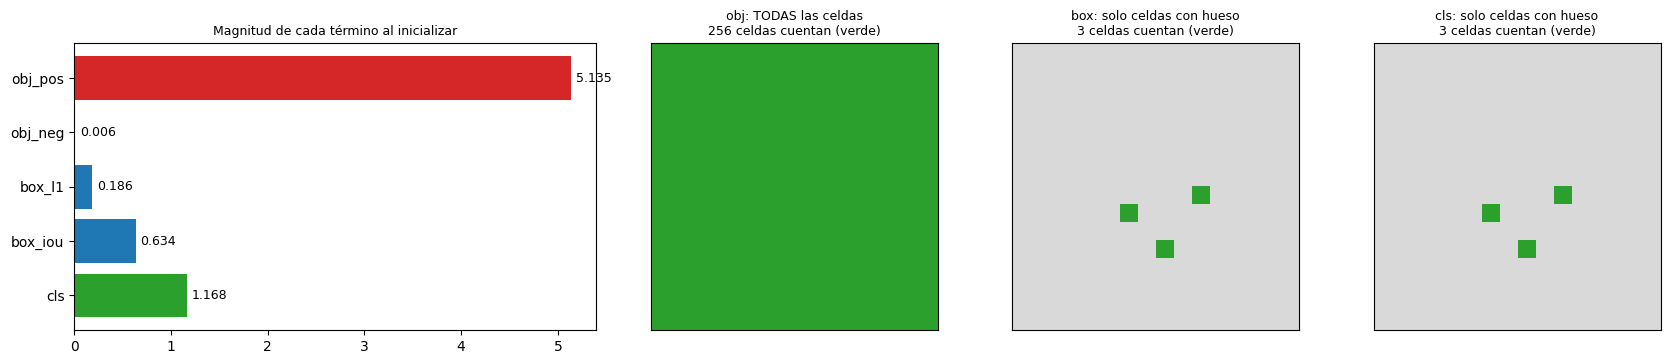

In [12]:
# Desglose de las tres pérdidas al inicializar (sin ponderar por λ)
with torch.no_grad():
    Li = grid_detection_loss(head(fm), T)
terminos = ["obj_pos", "obj_neg", "box_l1", "box_iou", "cls"]
for k in terminos:
    print(f"  {k:<8} {Li[k].item():.4f}")
print(f"  IoU medio inicial de la caja en las celdas con hueso: {Li['mean_iou'].item():.3f}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(17, 3.6), gridspec_kw={"width_ratios": [1.6, 1, 1, 1]})
valores = [Li[k].item() for k in terminos]
ax1.barh(terminos[::-1], valores[::-1], color=["#2ca02c", "#1f77b4", "#1f77b4", "#d62728", "#d62728"])
for i, v in enumerate(valores[::-1]):
    ax1.text(v + 0.05, i, f"{v:.3f}", va="center", fontsize=9)
ax1.set_title("Magnitud de cada término al inicializar", fontsize=9)
pos_k = (T["obj_t"][1] > 0.5).numpy()                                      # qué celdas cuenta cada pérdida (imagen 1)
for ax, (titulo, contada) in zip((ax2, ax3, ax4), [("obj: TODAS las celdas", np.ones_like(pos_k)), ("box: solo celdas con hueso", pos_k), ("cls: solo celdas con hueso", pos_k)]):
    ax.imshow(contada, cmap=ListedColormap(["#d9d9d9", "#2ca02c"]), vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{titulo}\n{int(contada.sum())} celdas cuentan (verde)", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Mini-overfit: ¿la cabeza y la pérdida pueden aprender?

Entrenamos **solo la cabeza** para memorizar las 12 cajas del batch fijo (con los mapas sintéticos de la sección 3). Si no pudiera memorizar 6 imágenes habría un error en los objetivos, la cabeza o la pérdida.

**Qué demuestra y qué no:** demuestra que las tres piezas son coherentes entre sí. **No** demuestra que generalice; la prueba con el backbone real es el overfit de Hoyos.

Receta: AdamW (lr 2e-3), el learning rate **decae con un coseno hasta 0** y 1200 pasos (~25 s en CPU). En las pruebas previas, esa receta llevó el IoU medio a 0.917 en las tres semillas (con 400 pasos y lr constante: 0.84).

In [13]:
def entrenar_cabeza(pasos=1200, lr=2e-3, semilla=SEED):
    torch.manual_seed(semilla)
    h = GridDetectionHead(obj_prior=OBJ_PRIOR, wh_prior=WH_PRIOR).to(DEVICE)
    opt = torch.optim.AdamW(h.parameters(), lr=lr, weight_decay=0.0)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=pasos)   # el lr baja hasta 0: la caja se afina al final
    hist = {"obj": [], "box": [], "cls": [], "mean_iou": []}
    for paso in range(pasos + 1):
        L = grid_detection_loss(h(fm), T)
        for k in hist:
            hist[k].append(L[k].item())
        if paso == pasos:
            break
        opt.zero_grad()
        L["total"].backward()
        opt.step()
        sched.step()
    return h, hist


@torch.no_grad()
def iou_por_caja(h):
    """IoU de la caja que predice la celda responsable contra la caja real, para cada una de las 12 cajas."""
    _, box_logit, _ = split_head_output(h(fm).float())
    b, r, c = [x.to(DEVICE) for x in (T["obj_t"] > 0.5).nonzero(as_tuple=True)]
    return box_iou(decode_boxes(r, c, torch.sigmoid(box_logit[b, r, c])), decode_boxes(r, c, T["box_t"].to(DEVICE)[b, r, c])).cpu()


head_ent, hist = entrenar_cabeza()
ious = iou_por_caja(head_ent)
with torch.no_grad():
    prob = torch.sigmoid(head_ent(fm)[:, CH_OBJ]).cpu()
tp, fp = int(((prob > 0.5) & pos).sum()), int(((prob > 0.5) & ~pos).sum())

# Controles
assert hist["obj"][-1] < 0.1 * hist["obj"][0]          # objectness aprendió
assert hist["mean_iou"][-1] > 0.8                       # las cajas encajan
print(f"IoU medio: {hist['mean_iou'][0]:.3f} -> {hist['mean_iou'][-1]:.3f} | cajas con IoU < 0.5: {int((ious < 0.5).sum())} de {len(ious)}")
print(f"Celdas con hueso detectadas (P > 0.5): {tp} de {int(pos.sum())} | falsos positivos: {fp}")

IoU medio: 0.307 -> 0.917 | cajas con IoU < 0.5: 1 de 12
Celdas con hueso detectadas (P > 0.5): 12 de 12 | falsos positivos: 0


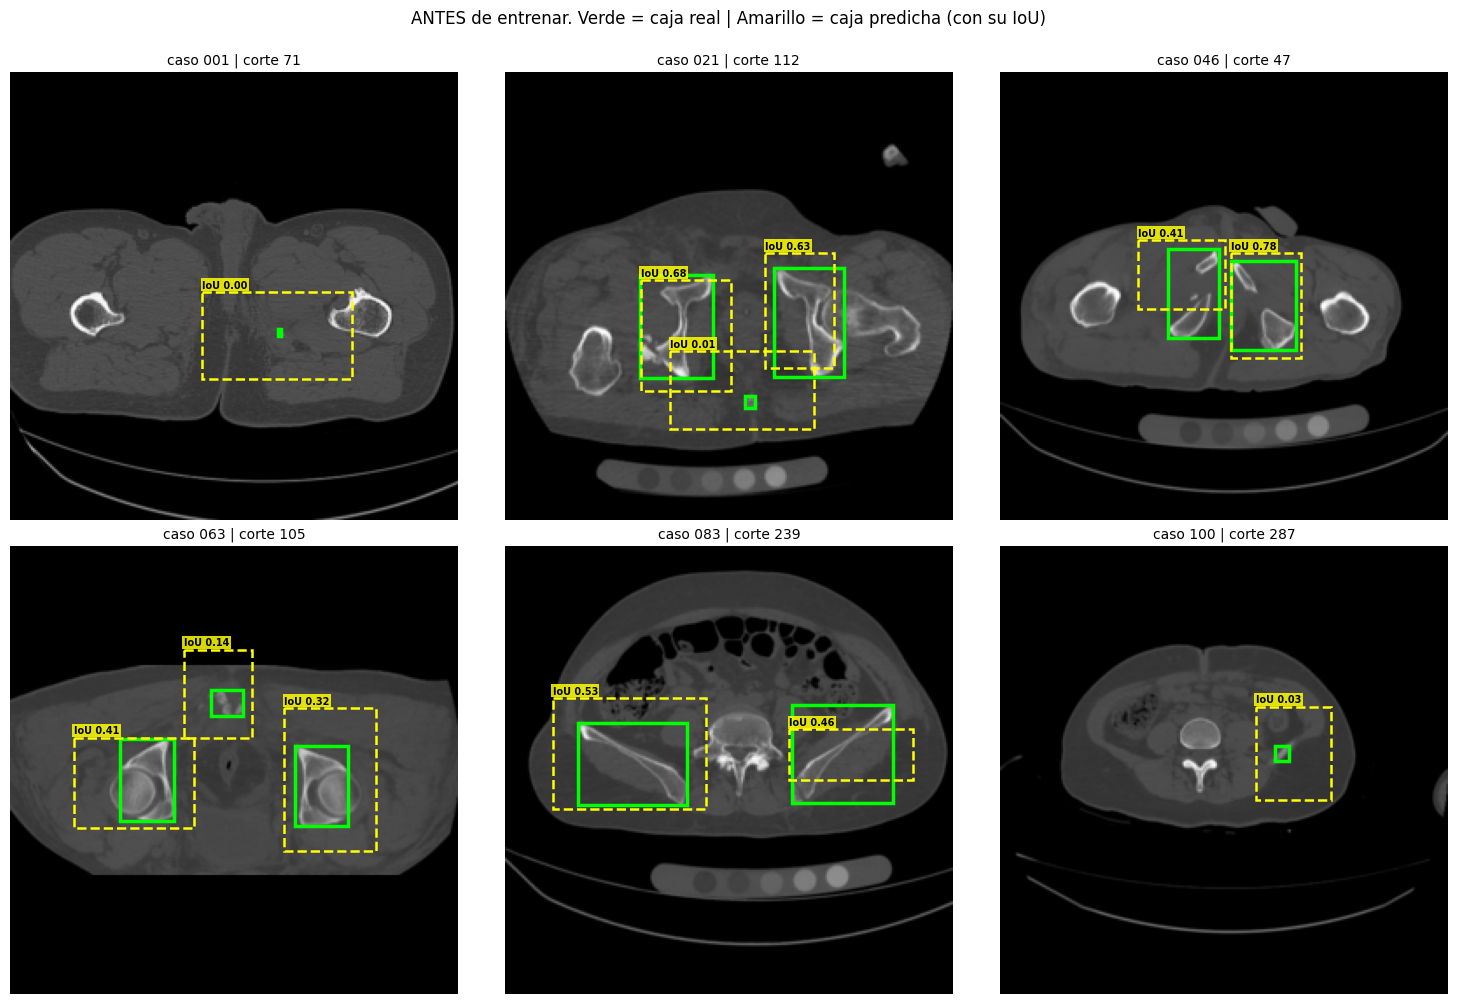

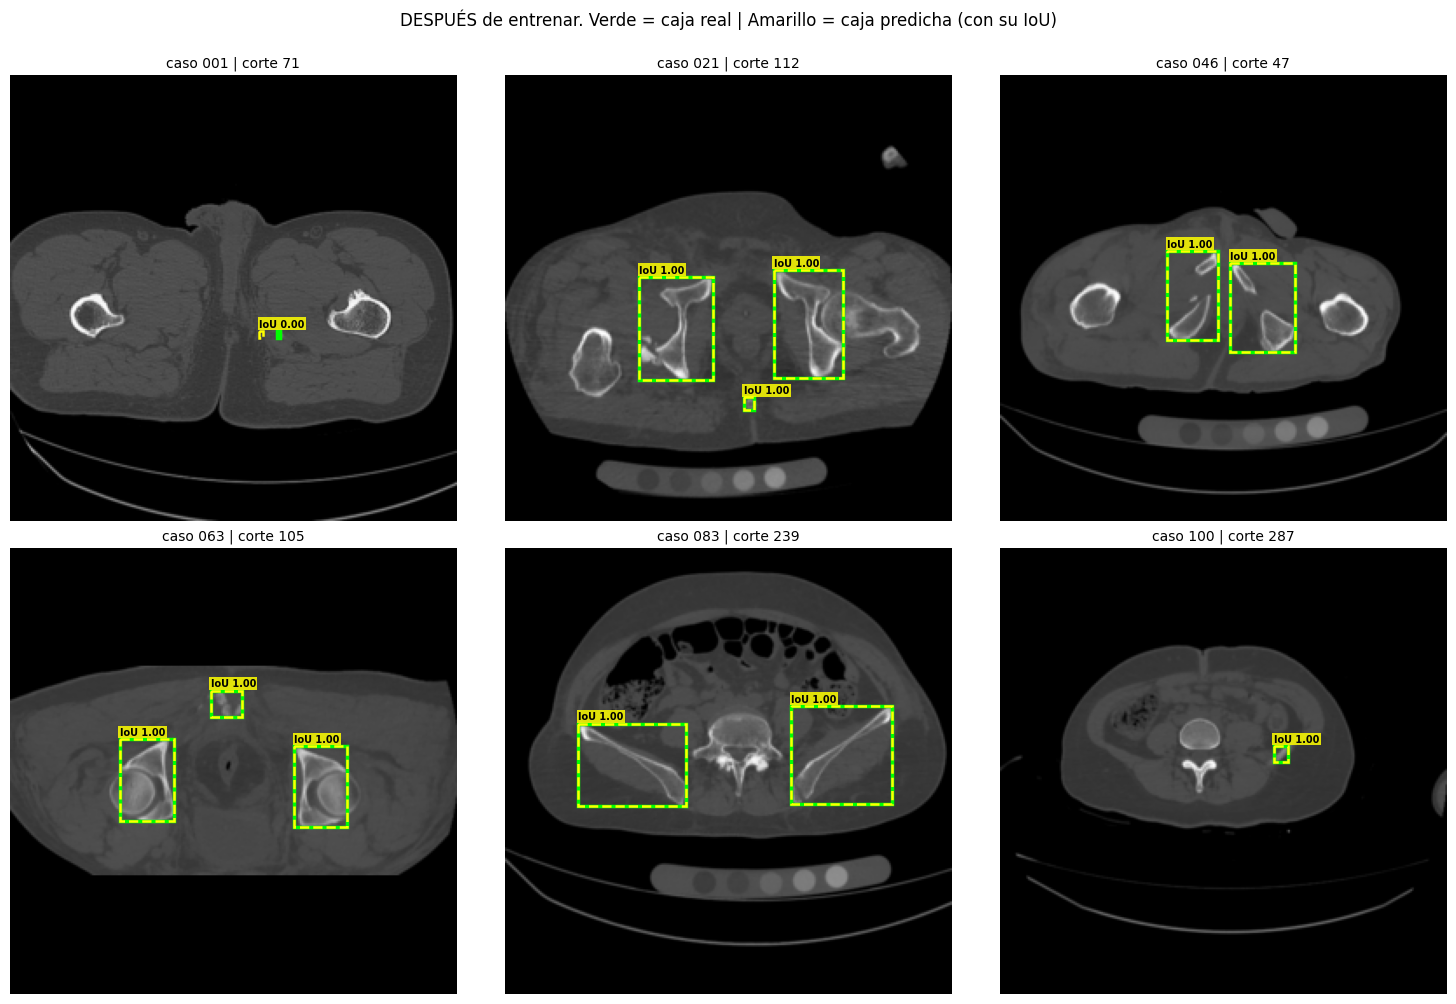

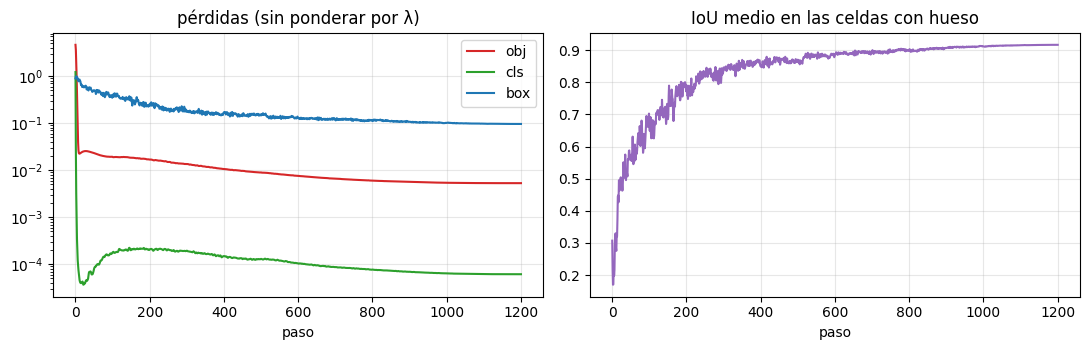

In [14]:
@torch.no_grad()
def dibujar_pred_vs_gt(h, titulo):
    """Caja real (verde) contra la caja que predice la celda responsable (amarillo), con su IoU."""
    _, box_logit, _ = split_head_output(h(fm).float().cpu())
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for k, ax in enumerate(axes.ravel()):
        ax.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
        for i, j in T["obj_t"][k].nonzero().tolist():
            ri, ci = torch.tensor([i]), torch.tensor([j])
            b_pred = decode_boxes(ri, ci, torch.sigmoid(box_logit[k, i, j])[None])
            b_gt = decode_boxes(ri, ci, T["box_t"][k, i, j][None])
            dibujar_caja(ax, b_gt[0], "lime", lw=2.5)
            dibujar_caja(ax, b_pred[0], "yellow", lw=1.8, ls="--", texto=f"IoU {box_iou(b_pred, b_gt).item():.2f}")
        ax.set_title(f"caso {targets[k]['case_id']} | corte {targets[k]['slice_index']}", fontsize=10)
        ax.axis("off")
    plt.suptitle(titulo, y=1.0)
    plt.tight_layout()
    plt.show()

dibujar_pred_vs_gt(head, "ANTES de entrenar. Verde = caja real | Amarillo = caja predicha (con su IoU)")
dibujar_pred_vs_gt(head_ent, "DESPUÉS de entrenar. Verde = caja real | Amarillo = caja predicha (con su IoU)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
for k, c in [("obj", "tab:red"), ("cls", "tab:green"), ("box", "tab:blue")]:
    a1.plot(hist[k], label=k, color=c)
a1.set_yscale("log"); a1.set_xlabel("paso"); a1.set_title("pérdidas (sin ponderar por λ)"); a1.legend(); a1.grid(alpha=0.3)
a2.plot(hist["mean_iou"], color="tab:purple"); a2.set_xlabel("paso"); a2.set_title("IoU medio en las celdas con hueso"); a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Cómo se eligieron los λ** (anexo): 4 configuraciones con 3 semillas, términos sin ponderar, 400 pasos:

| Configuración | IoU medio (últimos 50 pasos) |
|---|---|
| A: todo en 1.0 | 0.816 ± 0.011 |
| **B: equilibrio de magnitudes (obj 0.46, box 2.90, cls 2.03)** | **0.840 ± 0.007** |
| C: caja ×5 (como el CenterNet de S7_2) | 0.832 ± 0.026 |
| D: sin el término IoU (solo L1) | 0.829 ± 0.011 (arranque inestable) |

B fue la mejor y la más estable. También se probó GIoU (peor y mucho más inestable: 0.823 ± 0.070), así que se descartó.

**Una limitación a tener presente:** la caja más pequeña (2×4 px, caso 001) queda con IoU 0 (es la "1 de 12" de arriba). La red predice bien su tamaño, pero la sigmoide de `tx` se satura en el borde de la celda y el gradiente casi desaparece. Una opción para probar con el modelo completo es no usar sigmoide en `tx, ty` (como el `off` del CenterNet del profesor). No está probada.

## 6. Decodificar las predicciones y dejar listo el NMS

La red entrega logits. Para dibujar cajas, medir el IoU contra el GT y aplicar el NMS hace falta convertirlos en **cajas, scores y clases**:

- Cada celda produce **una candidata**: `score = objectness × probabilidad de su clase`.
- Las candidatas salen **ordenadas por score** (todo NMS parte de ahí) y con clases 1, 2, 3 como en el dataset.
- `postprocess` acepta una función `nms_fn(boxes, scores, labels, iou_thresh)` que devuelve los índices a conservar: ahí se enchufa el NMS propio de la próxima semana.

In [15]:
@torch.no_grad()
def decode_predictions(out, score_thresh=0.0, img_size=IMG_SIZE):
    """Logits [B,8,S,S] -> lista de B dicts con una candidata por celda, ordenadas por score (mayor a menor):
    boxes [N,4] xyxy en px | scores [N] = objectness x prob. de clase | labels [N] en 1..3 | cells [N,2] = (fila, columna)."""
    out = out.float()
    obj_logit, box_logit, cls_logit = split_head_output(out)
    B, S = obj_logit.shape[0], obj_logit.shape[1]
    cls_score, cls_idx = torch.softmax(cls_logit, dim=-1).max(dim=-1)
    score = torch.sigmoid(obj_logit) * cls_score
    t = torch.sigmoid(box_logit)
    rows = torch.arange(S, device=out.device).view(S, 1).expand(S, S).reshape(-1)
    cols = torch.arange(S, device=out.device).view(1, S).expand(S, S).reshape(-1)
    results = []
    for b in range(B):
        boxes = decode_boxes(rows, cols, t[b].reshape(-1, 4), img_size, S).clamp(0, img_size)
        sc, lb = score[b].reshape(-1), cls_idx[b].reshape(-1) + 1      # clases 0..2 -> 1..3
        keep = (sc >= score_thresh).nonzero(as_tuple=True)[0]
        keep = keep[sc[keep].argsort(descending=True)]                 # el NMS parte de scores ordenados
        results.append({"boxes": boxes[keep], "scores": sc[keep], "labels": lb[keep],
                        "cells": torch.stack([rows[keep], cols[keep]], dim=1)})
    return results


def postprocess(out, score_thresh=0.05, nms_fn=None, iou_thresh=0.5):
    """decode_predictions + NMS opcional. nms_fn(boxes, scores, labels, iou_thresh) -> índices a conservar."""
    preds = decode_predictions(out, score_thresh)
    if nms_fn is None:
        return preds
    final = []
    for p in preds:
        keep = nms_fn(p["boxes"], p["scores"], p["labels"], iou_thresh)
        final.append({k: v[keep] for k, v in p.items()})
    return final

In [16]:
# Controles
preds = decode_predictions(logits_perfectos(T), score_thresh=0.5)
for k, p in enumerate(preds):
    gt = targets[k]["boxes"].to(p["boxes"].device)
    assert len(p["boxes"]) == len(gt)                                                       # una candidata por cada caja real
    assert bool((pairwise_iou(p["boxes"], gt).max(dim=1).values > 0.99).all())              # que coincide con su caja real
    assert set(p["labels"].tolist()) == set(targets[k]["labels"].tolist())                  # y con su clase
todas_c = decode_predictions(head(fm), score_thresh=0.0)
assert all(len(p["boxes"]) == GRID_S * GRID_S and bool((p["scores"][:-1] >= p["scores"][1:]).all()) for p in todas_c)   # 256 candidatas ordenadas
solo_una = postprocess(head(fm), score_thresh=0.0, nms_fn=lambda b, s, l, t: torch.arange(1))                          # el enchufe del NMS funciona
assert all(len(p["boxes"]) == 1 for p in solo_una)
print("Decodificación: con logits perfectos se recuperan las 12 cajas y sus clases; las candidatas salen ordenadas; el enchufe del NMS funciona")

Decodificación: con logits perfectos se recuperan las 12 cajas y sus clases; las candidatas salen ordenadas; el enchufe del NMS funciona


## 7. Resumen para Hoyos (y para explicarlo)

**Cómo usar mi parte** (todo está en `deteccion_grid.py`, con las mismas funciones de este notebook):

```python
from deteccion_grid import GridDetectionHead, build_targets, grid_detection_loss, postprocess, LAMBDAS

_, fmap = backbone(x)                         # backbone de Miguel: devuelve la tupla (pooled, fmap)
fmap, _, _ = cbam(fmap)                       # CBAM / compuerta de Annie: devuelve (y, ch_attn, sp_attn); solo se usa y
head = GridDetectionHead()                    # entrada: mapa [B, 256, 16, 16] (backbone + CBAM)
out = head(fmap)                              # [B, 8, 16, 16]: logits
T = build_targets(targets)                    # targets: lista de dicts con 'boxes' (xyxy, px) y 'labels' (1, 2, 3)
L = grid_detection_loss(out, T)               # dict: total, obj, box, cls, mean_iou...
L["total"].backward()
preds = postprocess(out, score_thresh=0.05, nms_fn=None)    # el NMS propio se enchufa en nms_fn
```

**Qué le sugiero a Hoyos:**
- Entrenar con AdamW, el learning rate decayendo con un coseno hasta 0 y al menos ~1000 pasos (así subió el IoU de 0.84 a 0.92 en esta prueba).
- Registrar `obj`, `box`, `cls` por separado (el diccionario ya los trae).
- Reconfirmar los λ con el modelo completo: aquí se eligieron con la cabeza sola y mapas sintéticos.
- Recalcular también los priors de la cabeza con el dataset completo: `obj_prior` (fracción de celdas con hueso, aquí 0.0078) y `wh_prior` (tamaño inicial de la caja, aquí 0.20) salen de las 12 cajas del batch fijo.
- El CBAM y la compuerta residual con γ de Annie devuelven una tupla `(y, ch_attn, sp_attn)`; al empalmar, a la cabeza solo se le pasa `y` (ver el código de arriba).
- Para volver a correr este notebook se necesita `evidencias/batch_fijo.pt` (el batch fijo de Daniela); si está en otra carpeta, ajustar la ruta en la primera celda de código.

**Resultados verificados:**

| Qué | Resultado |
|---|---|
| IoU | 1.0, 0.0 y 1/7 en los 3 casos del profesor |
| Codificación | ida y vuelta exacta con las 12 cajas reales |
| Asignación | 12 cajas = 12 celdas con hueso + 0 colisiones |
| Cabeza | salida `[B, 8, 16, 16]`, 296,200 parámetros, el gradiente llega al mapa de entrada |
| Pérdidas | el fondo no cuenta en caja ni clase; sin NaN con batch vacío ni logits extremos |
| Mini-overfit | IoU medio 0.31 → 0.92; 12 de 12 celdas detectadas |

**Limitaciones:** una sola celda positiva por objeto; la caja de 2×4 px no converge (saturación de `tx`); todas las pruebas usan 12 cajas y mapas sintéticos.

**Pendiente del equipo:** NMS propio (se enchufa en `nms_fn`), integración con el backbone y el CBAM (el empalme), y reconfirmar λ y priors con el modelo completo.